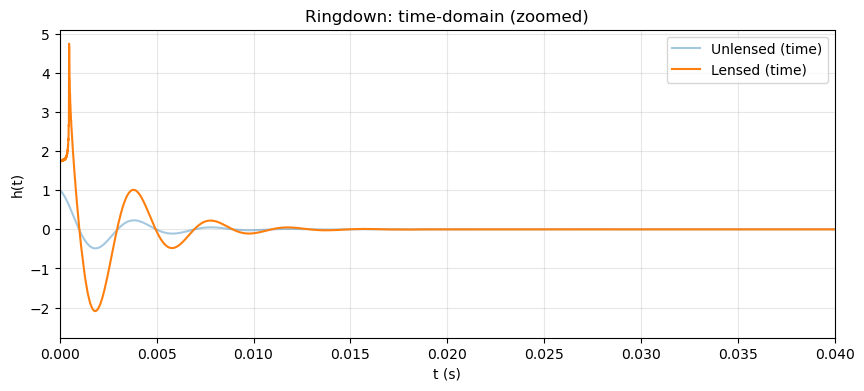

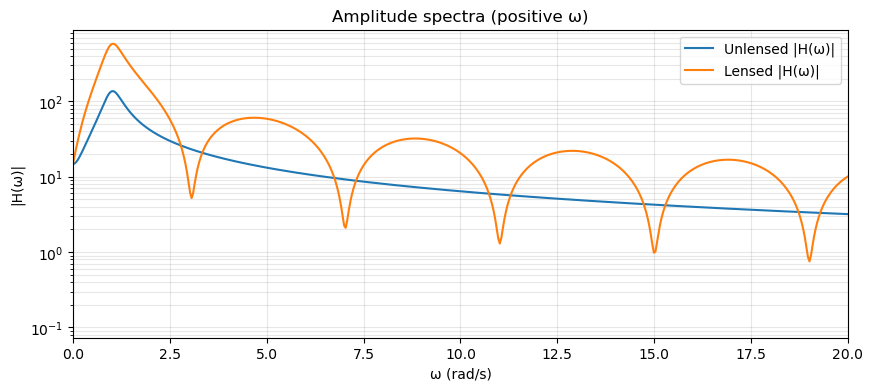

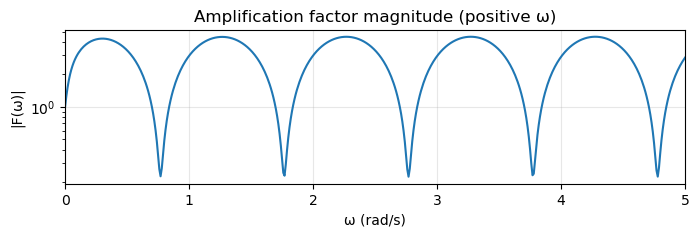

DC F[0] = (1+0j)
Some positive-frequency samples (omega_tilde, |F|):
  k=1, omega_tilde=3.976e-02, |F|=1.253e+00
  k=200, omega_tilde=7.953e+00, |F|=2.988e+00
  k=1000, omega_tilde=3.976e+01, |F|=2.567e+00
  k=2000, omega_tilde=7.953e+01, |F|=1.912e+00


In [15]:
import numpy as np
import matplotlib.pyplot as plt
import mpmath
from scipy.constants import pi
from scipy.fft import fft, ifft, fftfreq, fftshift, ifftshift

# ---------------------------
# Ringdown + lensing (clean implementation)
# ---------------------------

# Physical / model parameters (as in your snippet)
h0 = 1.0
nu0 = 5/4.0
M_sun = 1.0  # we'll keep M_sun symbolic (units cancel in f0 below)
M_lens = 250 * M_sun
M_source = 0.24 * M_lens / nu0
f0 = 1.207e4 * (M_sun / M_source)   # Hz
Gamma = 1.496 * f0
omega0 = 2 * pi * f0
y = 0.1

# time array
t = np.linspace(0, 0.1, 10000)
dt = t[1] - t[0]
N = len(t)

# time-domain ringdown (real)
h = h0 * np.exp(-Gamma * t) * np.cos(omega0 * t)

# Fourier transform (unshifted)
H = fft(h)            # length N, index 0 = DC
omega = 2 * pi * fftfreq(N, d=dt)   # angular frequencies in rad/s
omega_tilde = omega / omega0        # dimensionless frequency


# Build amplification factor F(omega) for all frequency bins (unshifted ordering)
# We will:
#  - set F[0] = 1 (limit omega->0)
#  - for k = 1 .. kpos_max (positive freqs), compute F(k) using hyp1f1 and amplitude factor
#  - impose Hermitian symmetry: F[-k] = conj(F[k]) so time-domain remains real

F = np.empty(N, dtype=complex)

# index ranges
# for numpy fft ordering: positive frequencies indices are 1 .. N//2 (if N even),
# negative frequencies are N//2+1 .. N-1
k_pos_max = N//2  # includes Nyquist if N even

# DC component
F[0] = 1.0 + 0j

# helper: compute hypergeometric safely with mpmath and convert to python complex
def hyp1f1_complex(a, b, z):
    # mpmath uses arbitrary precision; convert inputs to mpmath.mpc
    am = mpmath.mpc(a.real, a.imag)
    bm = mpmath.mpc(b.real, b.imag)
    zm = mpmath.mpc(z.real, z.imag)
    val = mpmath.hyper([am], [bm], zm)  # hyp1f1 is hyper([a],[b],z)
    return complex(val)

# compute for positive frequencies
for k in range(1, k_pos_max + 1):
    w = omega[k]
    wt = omega_tilde[k]
    if wt <= 0:
        # numerical safety: if zero or negative (shouldn't happen here for k>0), skip
        F[k] = 1.0 + 0j
        continue

    # confluent hypergeometric argument and prefactors (following your formula)
    # Using variables as in your snippet: hyp1f1( i*pi*nu0*wt, 1, i*pi*nu0*wt*y^2 )
    a = 1j * pi * nu0 * wt
    b = 1.0
    z = 1j * pi * nu0 * wt * (y**2)

    # compute hypergeometric 1F1(a, b; z)
    try:
        Hgeo = hyp1f1_complex(a, b, z)
    except Exception as exc:
        # fallback: if mpmath fails, set to 1 (will not be perfect)
        Hgeo = 1.0 + 0j

    # amplitude factor (avoid division by zero  ; wt>0 here)
    num = 2.0 * (pi**2) * nu0 * wt
    denom = 1.0 - np.exp(-2.0 * (pi**2) * nu0 * wt)
    Famp = np.sqrt(num / denom)

    F[k] = Famp * Hgeo

# Nyquist frequency handling when N is even: omega[N/2] is Nyquist (real), ensure real F
if N % 2 == 0:
    # ensure F[k_pos_max] is real (conjugate symmetry), but we already computed it for k_pos_max
    F[k_pos_max] = F[k_pos_max].real + 0j

# impose Hermitian symmetry for negative frequencies
# indices k = 1..k_pos_max correspond to positive freqs; negative indices wrap as N-k
for k in range(1, k_pos_max + 1):
    F[-k] = np.conj(F[k])

# Sanity: no NaNs
if np.any(np.isnan(F)):
    print("Warning: NaNs present in F; replacing with 1.0 where NaN")
    F = np.where(np.isnan(F), 1.0 + 0j, F)

# Apply amplification factor to Fourier-domain ringdown
H_lensed = H * F

# Back to time domain
h_lensed = ifft(H_lensed).real

# ---------------------------
# Plots
# ---------------------------
plt.figure(figsize=(10,4))
plt.plot(t, h, alpha=0.4, label="Unlensed (time)")
plt.plot(t, h_lensed, label="Lensed (time)")
plt.xlim(0, 0.04)
plt.xlabel("t (s)")
plt.ylabel("h(t)")
plt.legend()
plt.title("Ringdown: time-domain (zoomed)")

plt.grid(alpha=0.3)
plt.show()

# Frequency-domain plots (positive half)
freq = fftshift(fftfreq(N, d=dt))  # in cycles/s
omega_shifted = fftshift(omega_tilde)
H_shift = fftshift(H)
H_l_shift = fftshift(H_lensed)
F_shift = fftshift(F)

# plot amplitude spectra (positive part)
mid = N//2
plt.figure(figsize=(10,4))
plt.plot(omega_shifted[mid:], np.abs(H_shift[mid:]), label="Unlensed |H(ω)|")
plt.plot(omega_shifted[mid:], np.abs(H_l_shift[mid:]), label="Lensed |H(ω)|")
#plt.xlim(0, 50 * omega0)  # show a range relative to omega0 (may be large)
plt.xlim(0, 20)
plt.yscale('log')
plt.xlabel("ω (rad/s)")
plt.ylabel("|H(ω)|")
plt.legend()
plt.grid(which='both', alpha=0.3)
plt.title("Amplitude spectra (positive ω)")
plt.show()

# show amplification factor magnitude for positive ω
plt.figure(figsize=(8,2))
plt.plot(freq[mid:]/10**3, np.abs(F_shift[mid:]))
#plt.xlim(0, 50 * omega0)
plt.xlim(0, 5)
plt.yscale('log')
plt.xlabel("ω (rad/s)")
plt.ylabel("|F(ω)|")
plt.title("Amplification factor magnitude (positive ω)")
plt.grid(alpha=0.3)
plt.show()

# Print a few diagnostics
print("DC F[0] =", F[0])
print("Some positive-frequency samples (omega_tilde, |F|):")
for k in [1, max(2, N//50), N//10, N//5]:
    print(f"  k={k}, omega_tilde={omega_tilde[k]:.3e}, |F|={abs(F[k]):.3e}")
